# Wine Dataset

The following notebook implements Principal Component Analysis (PCA) on the Wine Dataset for dimensionality reduction, an unsupervised learning task. The goal is to reduce the dataset from a dimension of 13 features, to one of 3 non-correlated and transformed features that preserve the most information while reducing data complexity and allowing for data visualization.

**Main Objectives and Tasks:**
- <u>Import the data
- Exploratory Data Analysis (EDA)
- Preprocess data and standardization
- Build Principal Component Analysis with sklearn
- Evaluation and plots
- Reconstruction and Explained Variance</u>

**Extra:**
- <u>Implement the Principal Component Analysis (PCA) algorithm from scratch
- Develop various data visualizations related to the algorithm</u>

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn

## Principal Component Analysis (PCA) Implementation

**Principal Component Analysis (PCA)** is a dimensionality reduction technique that reduces the number of features in a dataset while preserving the most important information.

It transforms correlated features into a smaller set of uncorrelated ones by computing eigenvalues (importance) and eigenvectors (direction) from the covariance matrix, selecting the top $K$ components with the highest eigenvalues, and linearly projecting the data onto them.

The objective is to **maximize the projected variance** via the empirical covariance matrix:

$$
\overset{\scriptscriptstyle\wedge}{\Sigma} = \frac{1}{n - 1} \sum_{i=1}^{n} (x_i - \overset{\scriptscriptstyle\wedge}{\mu})(x_i - \overset{\scriptscriptstyle\wedge}{\mu})^T
$$

where $\overset{\scriptscriptstyle\wedge}{\mu}$ is the empirical mean. The optimal subspace is spanned by the top $K$ eigenvectors of $\overset{\scriptscriptstyle\wedge}{\Sigma}$.

---

Projecting $x$ onto the subspace yields a code (representation) $z$:

$$
z = U^T(x^{(i)} - \overset{\scriptscriptstyle\wedge}{\mu})
$$

where $U$ is the orthonormal basis. The original data can be reconstructed from $z$ via:

$$
\overset{\scriptscriptstyle\sim}{x} = \overset{\scriptscriptstyle\wedge}{\mu} + Uz
$$

---

A key property of PCA is that the following three objectives are equivalent and yield the same solution:

**1. Minimize reconstruction error:**
$$\min_{U} \frac{1}{N}\sum^{N}_{i=1}\lVert x^{(i)}-\overset{\scriptscriptstyle\sim}{x}^{(i)}\rVert^2$$

**2. Maximize variance of the reconstruction:**
$$\max_{U} \frac{1}{N}\sum^{N}_{i=1}\lVert \overset{\scriptscriptstyle\sim}{x}^{(i)} - \overset{\scriptscriptstyle\wedge}{\mu} \rVert^2$$

**3. Maximize variance of the representation:**
$$\max_{U} \frac{1}{N}\sum^{N}_{i=1}\lVert z^{(i)} \rVert^2$$

---

**Note:** Minimizing reconstruction error is equivalent to maximizing the variance of the projected data — both objectives yield the same solution in PCA, namely the top eigenvectors of the covariance matrix. Variance here serves as a measure of information retained, so maximizing it ensures the projection preserves as much structure from the original data as possible.

In [238]:
class PrincipalComponentAnalysis():
  """
  This is a custom implementation of the Principal Component Analysis (PCA) algorithm.

  Parameters:
  - self.n_components is the number of top K eigenvectors to use for the linear projection of the data to codes.
  - self.mu_hat is the empirical mean of the current fit
  - self.U are is the orthonormal basis of the subspace formed by the top K principal components
  - self.top_eigenvals are the eigenvalues corresponding to the principal components
  - self.eigenvals is the list of eigenvalues

  """
  def __init__(self, n_components):
    self.n_components = n_components
    self.mu_hat = None
    self.U = None
    self.top_eigenvals = None
    self.eigenvals = None

  def fit_transform(self, X):
    """
    Fits the PCA to the data and returns the projected representations.

    Args:
      X: Input data of shape (N, d), assumed to be scaled.

    Returns:
      z: Projected data/codes/representations of shape (N, n_components)
    """
    # Assumes data is scaled
    # Get the Empirical Mean and find the Covariance Matrix
    mu_hat = np.mean(X, axis=0)
    N = X.shape[0]
    co_var_matrix = (1 / N) * (X - mu_hat).T @ (X - mu_hat)

    # Calculate the Eigenvectors and Eigenvalues of the covar matrixd
    eigenvalues, eigenvectors = np.linalg.eig(co_var_matrix)


    # Select the top K Principal Components (highest eigenvalues)
    top_eigenvals_index = np.argsort(eigenvalues, axis=0)[::-1][:self.n_components]
    top_eigenvals = np.sort(eigenvalues, axis=0)[::-1][:self.n_components]
    U = eigenvectors[:, top_eigenvals_index]

    # Linear projection of data into representations/codes
    z = (X - mu_hat) @ U

    # For Reconstruction
    self.mu_hat = mu_hat
    self.U = U
    self.top_eigenvals = top_eigenvals
    self.eigenvals = eigenvalues

    return z

  def reconstruction(self, z):
    """
    Uses the codes to attemnpt to reconstruct the original data.

    Args:
      z: Projected data/codes/representations of shape (N, n_components)

    Returns:
      X_tilde: Reconstructed data of shape (N, d), assumed to be scaled.
    """
    # Get reconstructed data from codes
    x_tilde = np.expand_dims(self.mu_hat, axis=1) + self.U @ z.T

    return x_tilde.T

  def explained_variance(self):
    """
    Computes the proportion of total variance explained by the top K components.

    Returns:
        float: Explained variance ratio in the range [0, 1].
    """
    return np.sum(self.top_eigenvals) / np.sum(self.eigenvals)


## Importing the Dataset

In [8]:
## Importing the wine dataset
columns = ["class", "alcohol", "malic_acid", "ash", "alcalinity_of_ash",
    "magnesium", "total_phenols", "flavanoids", "nonflavanoid_phenols",
    "proanthocyanins", "color_intensity", "hue",
    "od280_od315", "proline"]

wine_data = pd.read_csv("wine.csv", names=columns)

##Exploratory Data Analysis (EDA) and Data Preprocessing

In [9]:
wine_data.head()

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [10]:
wine_data.describe()

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Standardize the data to have mean 0 and standard deviation 1, essential for PCA.

In [42]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
scaled_data = standard_scaler.fit_transform(wine_data.iloc[:, 1:])
labels = wine_data["class"]

Inspecting both the feature scaling and correlation matrix (a heatmap) as strong correlations indicate redundancies which PCA can compress.

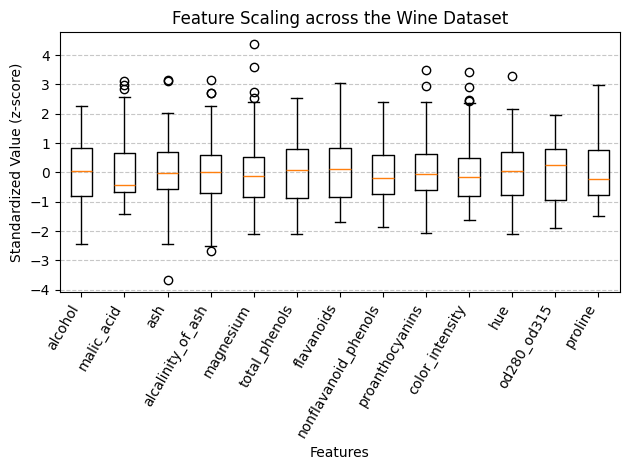

In [43]:
# Feature scaling boxplot
plt.boxplot(scaled_data)
plt.title("Feature Scaling across the Wine Dataset")
plt.xlabel("Features")
plt.ylabel("Standardized Value (z-score)")
plt.xticks(ticks=range(1, len(columns)), labels=columns[1:], rotation=60, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

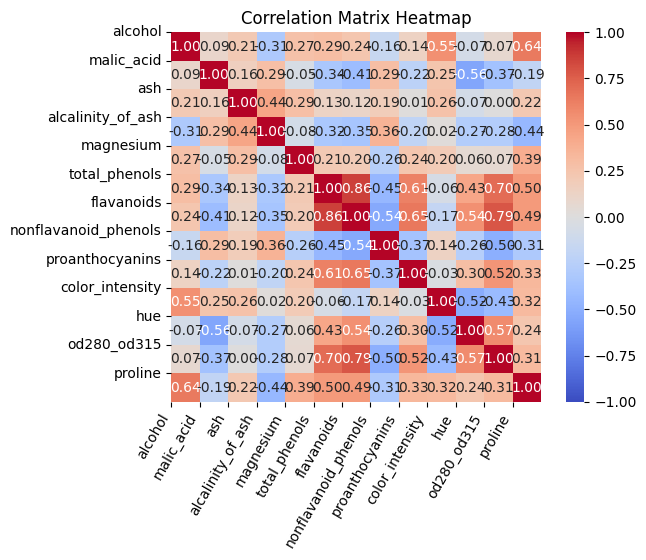

<Figure size 1000x800 with 0 Axes>

In [68]:
# Correlation matrix heatmap
correlation_matrix = np.corrcoef(scaled_data, rowvar=False)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", square=True)
plt.title("Correlation Matrix Heatmap")
plt.yticks(ticks=range(0, len(columns)-1), labels=columns[1:], rotation=0)
plt.xticks(ticks=range(0, len(columns)-1), labels=columns[1:], rotation=60, ha="right")
plt.figure(figsize=(10, 8))
plt.tight_layout()
plt.show()

## Building the Model

In [85]:
from sklearn.decomposition import PCA

# PCA with 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_data)

# PCA with 3 principal compponents
pca2 = PCA(n_components=3)
X_pca2 = pca2.fit_transform(scaled_data)

## Evaluation and Plots

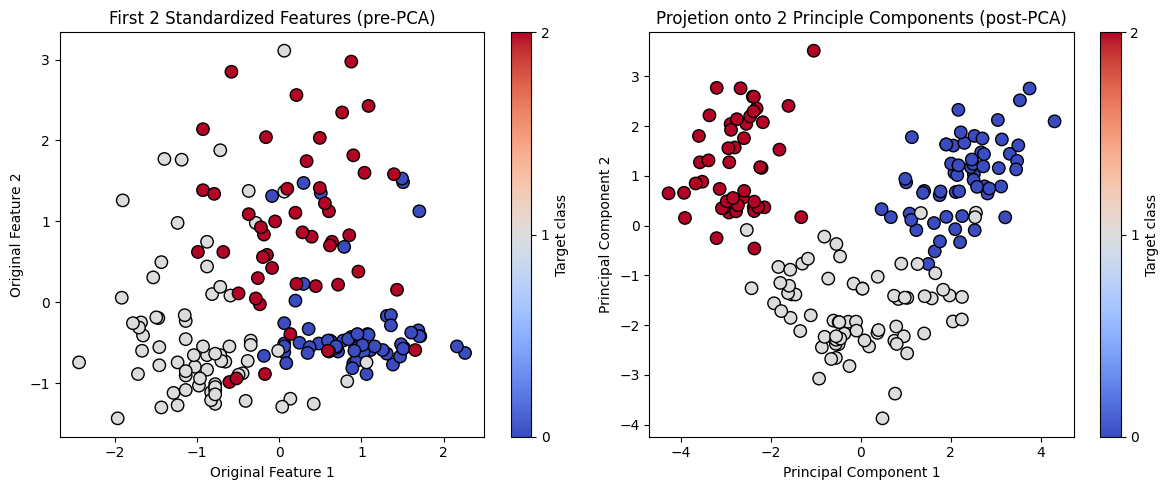

In [79]:
y_numeric = pd.factorize(labels)[0]
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel("Original Feature 1")
plt.ylabel("Original Feature 2")
plt.title("First 2 Standardized Features (pre-PCA)")
plt.colorbar(label="Target class", ticks=[0, 1, 2])

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Projetion onto 2 Principle Components (post-PCA)")
plt.colorbar(label="Target class", ticks=[0, 1, 2])

plt.tight_layout()
plt.show()

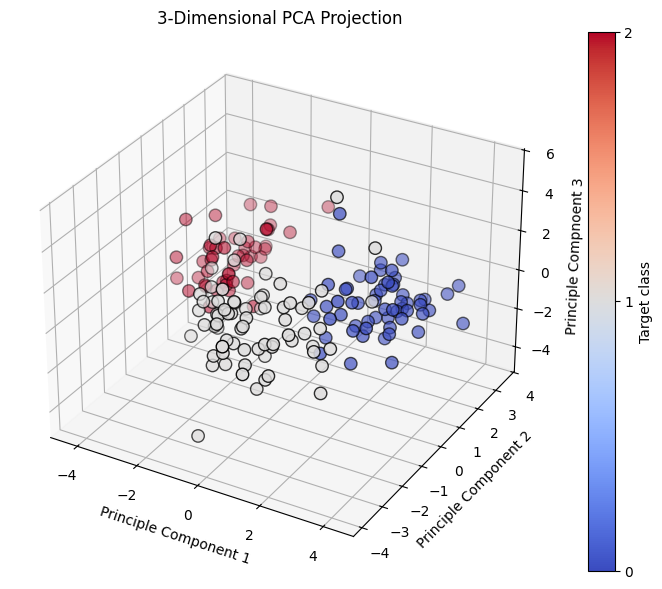

In [94]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_pca2[:, 0], X_pca2[:, 1],X_pca2[:, 2], c=y_numeric, cmap='coolwarm', s=80, edgecolor='k')

ax.set_xlabel("Principle Component 1")
ax.set_ylabel("Principle Component 2")
ax.set_zlabel("Principle Compnoent 3")
ax.set_title("3-Dimensional PCA Projection")

fig.colorbar(sc, label="Target class", ticks=[0, 1, 2])

plt.show()

## Testing Manual Implementation

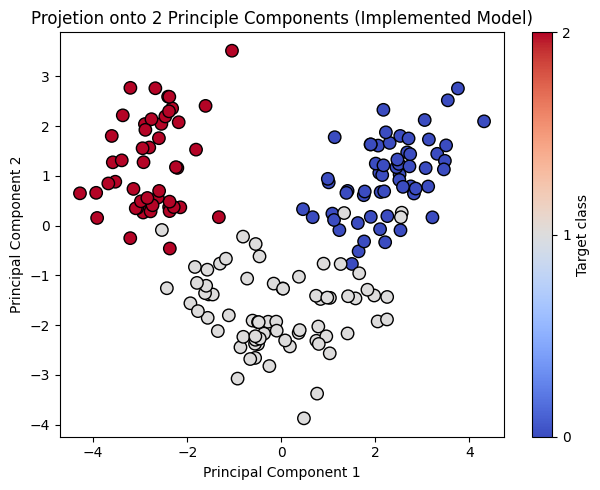

In [221]:
PCA_model1 = PrincipalComponentAnalysis(n_components=2)
x_pca_manual = PCA_model1.fit_transform(scaled_data)

y_numeric = pd.factorize(labels)[0]
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Projetion onto 2 Principle Components (Implemented Model)")
plt.colorbar(label="Target class", ticks=[0, 1, 2])

plt.tight_layout()
plt.show()


In [222]:
# Test reconstruction
x_reconstructed = PCA_model1.reconstruction(x_pca_manual)

In [230]:
explained_variance = PCA_model1.explained_variance()
print("The explained variance of the 2 Principal Components is: {0:.2f}%".format(explained_variance*100))

The explained variance of the 2 Principal Components is: 55.41%


In [231]:
# Compute reconstruction error
reconstruction_error = (1 / x_reconstructed.shape[0]) * np.sum(np.square(scaled_data - x_reconstructed))
print(reconstruction_error)

5.797176013598414


The high reconstruction error can be explained by the principal components discarding nearly half the variance, leading to a massive loss of information. Let's check if this changes with n_components=3.

In [235]:
PCA_model2 = PrincipalComponentAnalysis(n_components=3)
x_pca_manual2 = PCA_model2.fit_transform(scaled_data)

explained_variance2 = PCA_model2.explained_variance()
print("The explained variance of the 3 Principal Components is: {0:.2f}%".format(explained_variance2*100))

The explained variance of the 3 Principal Components is: 66.53%


In [236]:
# Test reconstruction
x_reconstructed2 = PCA_model2.reconstruction(x_pca_manual2)

In [237]:
# Compute reconstruction error
reconstruction_error2 = (1 / x_reconstructed2.shape[0]) * np.sum(np.square(scaled_data - x_reconstructed2))
print(reconstruction_error2)

4.351104043885918
